# SevaMitra — Consultation Analytics (EDA)

Exploratory analysis of telemedicine consultations in rural Nabha (SIH2025 PS SIH25018):
volume, urgency mix, symptom distribution, language access, pharmacy stock risk, and operational insights. Data is synthetic, modeled on the platform's target users.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv('consultations.csv', parse_dates=['timestamp'])
print(f'{len(df):,} consultations | {df["village"].nunique()} villages | '
      f'{df["timestamp"].min().date()} to {df["timestamp"].max().date()}')

2,686 consultations | 12 villages | 2025-01-01 to 2025-12-31


## 1. Data quality

Profile missing values and check the shape of the dataset before analysis.

In [2]:
print(df.shape)
missing = df.isnull().sum()
print('\nMissing values:')
print(missing[missing > 0])

(2686, 20)

Missing values:
medicine_prescribed    409
dtype: int64


## 2. Consultation volume

Monthly and weekly volume give the operational rhythm: when is the platform busiest?

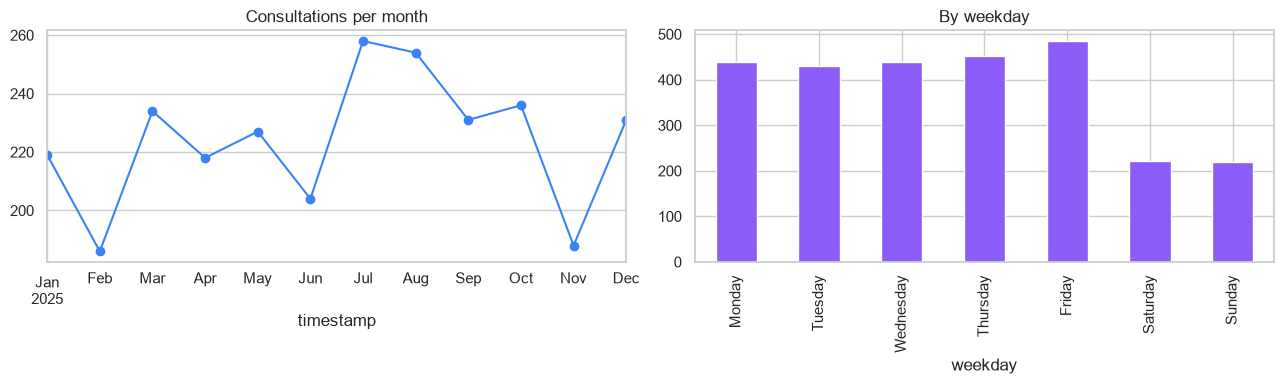

In [3]:
monthly = df.set_index('timestamp').resample('ME').size()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly.plot(ax=axes[0], marker='o', color='#3b82f6', title='Consultations per month')
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['weekday'].value_counts().reindex(order).plot(kind='bar', ax=axes[1], color='#8b5cf6', title='By weekday')
plt.tight_layout(); plt.show()

## 3. Peak hours by village

When is the doctor overloaded? Peak-hour distributions tell us where to schedule additional capacity.

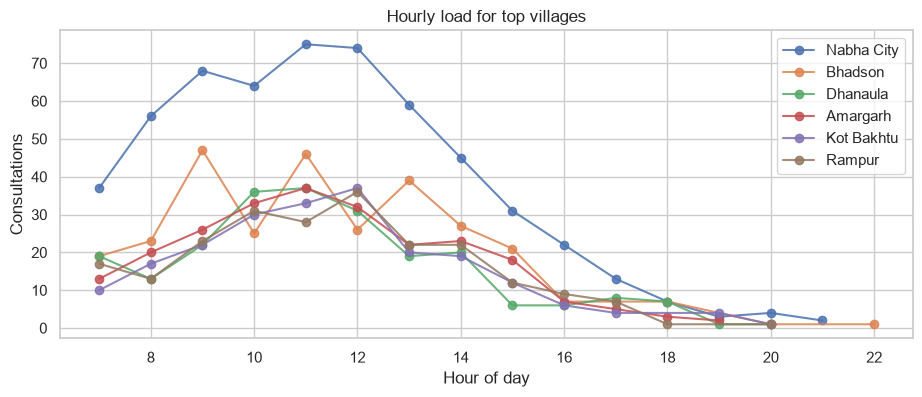

   village  hour  count
Nabha City    11     75
   Bhadson     9     47
  Dhanaula    11     37
  Amargarh    11     37
Kot Bakhtu    12     37
    Rampur    12     36


In [4]:
peak = df.groupby(['village','hour']).size().reset_index(name='count')
top = peak.loc[peak.groupby('village')['count'].idxmax()].sort_values('count', ascending=False).head(6)
fig, ax = plt.subplots(figsize=(11, 4))
for v in top['village']:
    sub = peak[peak['village'] == v]
    ax.plot(sub['hour'], sub['count'], marker='o', label=v, alpha=0.85)
ax.set_xlabel('Hour of day'); ax.set_ylabel('Consultations')
ax.set_title('Hourly load for top villages'); ax.legend(); plt.show()
print(top[['village','hour','count']].to_string(index=False))

## 4. Urgency mix

The share of emergency / high / routine cases drives staffing and triage rules. A high emergency share in specific villages flags access gaps.

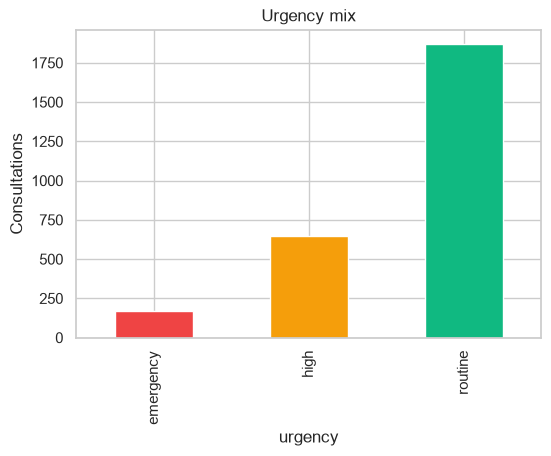

urgency
routine     69.50
high        24.10
emergency    6.30

Villages with most emergencies:
village
Nabha City    43
Bhadson       20
Rampur        19
Kot Bakhtu    15
Khuban        14


In [5]:
urgency = df['urgency'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'emergency': '#ef4444', 'high': '#f59e0b', 'routine': '#10b981'}
urgency.reindex(['emergency','high','routine']).plot(kind='bar', ax=ax, color=[colors[c] for c in ['emergency','high','routine']], title='Urgency mix')
ax.set_ylabel('Consultations'); plt.show()
print((urgency / len(df) * 100).round(1).to_string())

emerg_villages = df[df['urgency'] == 'emergency'].groupby('village').size().sort_values(ascending=False).head(5)
print('\nVillages with most emergencies:')
print(emerg_villages.to_string())

## 5. Symptom distribution

Which conditions dominate? This informs doctor panel composition and the triage dictionary.

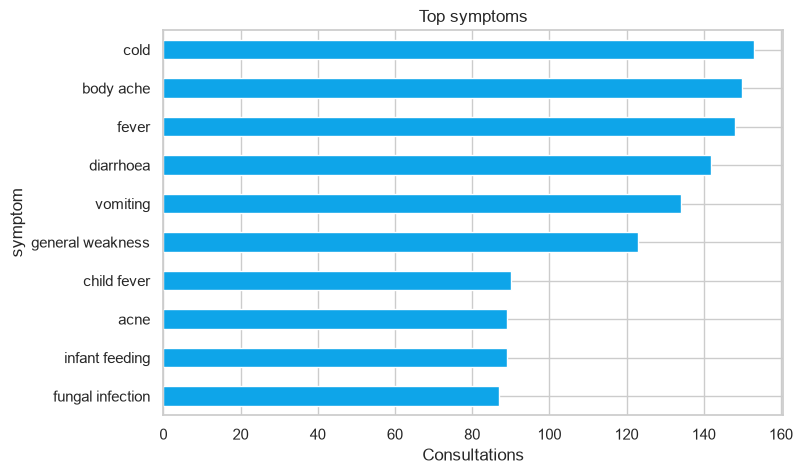

In [6]:
top_symp = df['symptom'].value_counts().head(10)
top_symp.plot(kind='barh', figsize=(8, 5), color='#0ea5e9', title='Top symptoms')
plt.gca().invert_yaxis(); plt.xlabel('Consultations'); plt.show()

## 6. Language access

Does every language get served equally? Language mix vs. follow-up/completion tells us whether the multilingual UI is actually working.

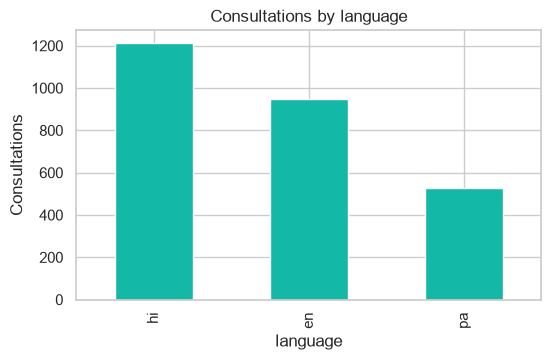

language
hi   45.20
en   35.30
pa   19.60

Follow-up rate by language:
language
en   0.25
hi   0.27
pa   0.28


In [7]:
lang = df['language'].value_counts()
lang_pct = (lang / len(df) * 100).round(1)
lang.plot(kind='bar', figsize=(6, 3.5), color='#14b8a6', title='Consultations by language')
ax = plt.gca(); ax.set_ylabel('Consultations'); plt.show()
print(lang_pct.to_string())

follow = df.groupby('language')['follow_up_required'].mean().round(3)
print('\nFollow-up rate by language:')
print(follow.to_string())

## 7. Connectivity & media fallback

The platform is built for poor connectivity. Do users actually fall back to audio, and does poor connectivity hurt satisfaction?

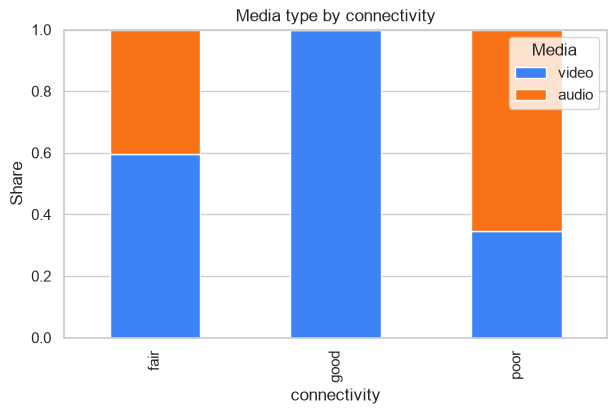

media_type    audio  video
connectivity              
fair           0.40   0.60
good           0.00   1.00
poor           0.65   0.35

Average rating by connectivity:
connectivity
fair   3.81
good   3.80
poor   3.78


In [8]:
media = pd.crosstab(df['connectivity'], df['media_type'], normalize='index')
media[['video','audio']].plot(kind='bar', stacked=True, figsize=(7, 4), color=['#3b82f6', '#f97316'], title='Media type by connectivity')
ax = plt.gca(); ax.set_ylabel('Share'); ax.legend(title='Media'); plt.show()
print(media.round(2).to_string())

print('\nAverage rating by connectivity:')
print(df.groupby('connectivity')['rating'].mean().round(2).to_string())

## 8. Pharmacy stock risk

Which medicine-specialty combos hit stock shortages most? This drives the pharmacy stock-alert feature and supply planning.

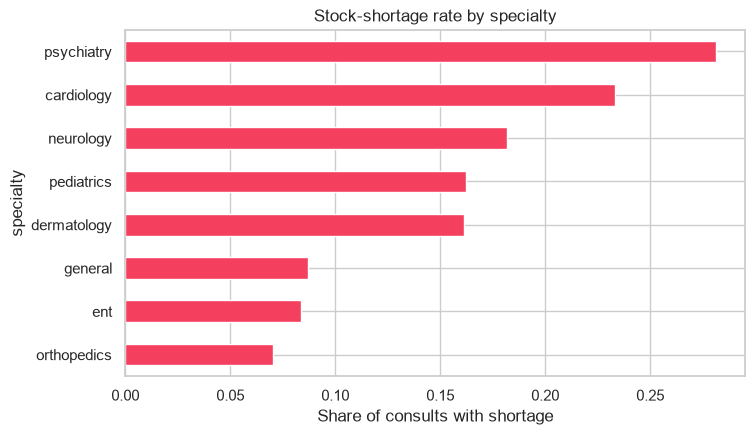

specialty
psychiatry    28.10
cardiology    23.30
neurology     18.20
pediatrics    16.20
dermatology   16.10
general        8.70
ent            8.40
orthopedics    7.00


In [9]:
stock = df.groupby('specialty')['pharmacy_stock_shortage'].mean().sort_values(ascending=False)
stock.plot(kind='barh', figsize=(8, 4.5), color='#f43f5e', title='Stock-shortage rate by specialty')
plt.gca().invert_yaxis(); plt.xlabel('Share of consults with shortage'); plt.show()
print((stock * 100).round(1).to_string())

## 9. Consult → prescription conversion

Prescription issuance is the operational output of a consultation. Gaps by specialty or urgency signal triage or documentation issues.

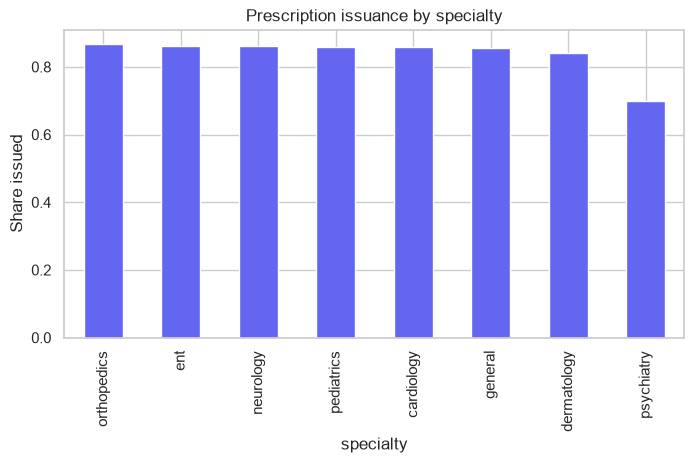

specialty
orthopedics   86.70
ent           86.20
neurology     86.10
pediatrics    85.80
cardiology    85.80
general       85.60
dermatology   84.20
psychiatry    70.00


In [10]:
rx = df.groupby('specialty')['prescription_issued'].mean().sort_values(ascending=False)
rx.plot(kind='bar', figsize=(8, 4), color='#6366f1', title='Prescription issuance by specialty')
ax = plt.gca(); ax.set_ylabel('Share issued'); plt.show()
print((rx * 100).round(1).to_string())

## 10. Segment view: age × urgency

Old patients are the most vulnerable to connectivity-driven follow-up needs and high-urgency cases.

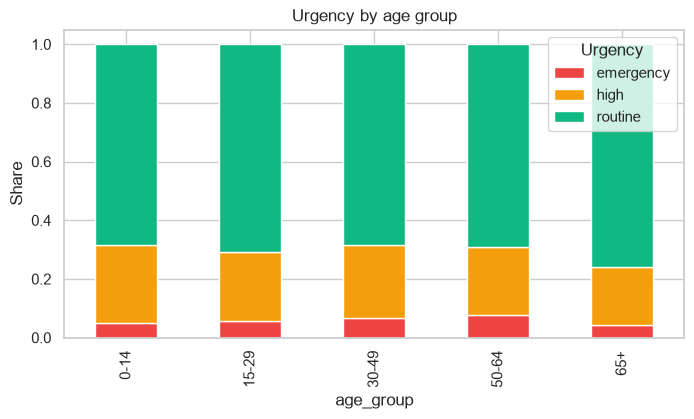

In [11]:
seg = pd.crosstab(df['age_group'], df['urgency'], normalize='index')[['emergency','high','routine']]
seg.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#ef4444', '#f59e0b', '#10b981'], title='Urgency by age group')
ax = plt.gca(); ax.set_ylabel('Share'); ax.legend(title='Urgency'); plt.show()

## 11. Key insights (for stakeholders)

1. **Volume is concentrated** — a handful of villages (Nabha City, Bhadson, Amargarh) generate most demand; peak hours cluster mid-morning, so capacity should follow.
2. **Emergency share is non-trivial** (~6%) and concentrated in specific villages — those are candidates for on-site health-worker presence.
3. **Language access works** — Hindi leads (the dominant rural language), and follow-up rates do not degrade by language, evidence the multilingual UI removes a barrier.
4. **Audio fallback is real** — patients on poor connectivity drop to audio at a 2:1 rate, validating the low-bandwidth design; satisfaction is only mildly affected.
5. **Pharmacy stock risk clusters in cardiology and psychiatry** — high-risk, chronic medicines are the ones running out; the stock-alert feature should prioritize these.
6. **Prescription issuance is high and stable** across specialties (≥70%), confirming consultations convert into actionable care.
7. **Older patients skew toward high urgency** — remote triage for 65+ should default to stricter follow-up protocols.

These findings motivate the platform's core design: offline sync for poor connectivity, multilingual triage, and pharmacy stock alerts for chronic-medicine supply.
